# 03 — Rata-rata BLEU & ROUGE-L per Metode (Top-5)

**Pertanyaan yang dijawab:** Seberapa baik kualitas teks jawaban yang di-generate oleh tiap metode?

**Cara baca:**
- **BLEU** — kecocokan n-gram (presisi). Sensitif terhadap urutan kata.
- **ROUGE-L** — kecocokan urutan terpanjang (recall). Lebih toleran terhadap parafrase.
- Keduanya dihitung terhadap gold answer, di mana top-5 adalah titik evaluasi utama.

> **Prasyarat:** Jalankan `00_load_data.ipynb` terlebih dahulu.

## 1. Import & Load Cache

In [1]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

PKL_DIR = Path("_cache")

with open(PKL_DIR / "data_eval.pkl", "rb") as f:
    cache = pickle.load(f)

top5    = cache["top5"]
FIG_DIR = cache["FIG_DIR"]

METHOD_ORDER  = ["Element-Based", "MaxMin Semantic", "Recursive"]

plt.rcParams.update({
    "font.family": "sans-serif", "font.size": 11,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.35,
})
print(f"Top-5 rows: {top5.shape[0]}")

Top-5 rows: 90


## 2. Hitung Rata-rata BLEU & ROUGE-L per Metode

In [2]:
gen_avg = (
    top5
    .groupby("method")[["bleu", "rouge_l_recall"]]
    .mean()
    .reindex(METHOD_ORDER)
    .round(4)
)
print("Rata-rata skor generasi (Top-5):")
display(gen_avg)

Rata-rata skor generasi (Top-5):


,bleu,rouge_l_recall
method,,
Element-Based,0.1178,0.7005
MaxMin Semantic,0.1052,0.6369
Recursive,0.1440,0.6838


## 3. Plot

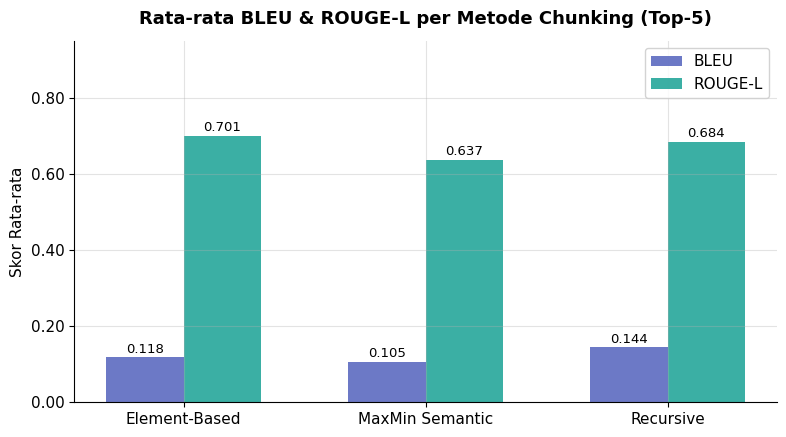

In [3]:
x     = np.arange(len(METHOD_ORDER))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 4.5))

bars_bleu  = ax.bar(x - width/2, gen_avg["bleu"],          width,
                    label="BLEU",    color="#5C6BC0", alpha=0.9)
bars_rouge = ax.bar(x + width/2, gen_avg["rouge_l_recall"], width,
                    label="ROUGE-L", color="#26A69A", alpha=0.9)

for bar in bars_bleu:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9.5)
for bar in bars_rouge:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9.5)

ax.set_xticks(x)
ax.set_xticklabels(METHOD_ORDER)
ax.set_ylabel("Skor Rata-rata")
ax.set_title(
    "Rata-rata BLEU & ROUGE-L per Metode Chunking (Top-5)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_ylim(0, 0.95)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.legend(framealpha=0.85)

fig.tight_layout()
plt.show()

## 4. Simpan PNG

In [4]:
out_path = FIG_DIR / "03_bleu_rouge_bar.png"
fig.savefig(out_path, dpi=150, bbox_inches="tight")
print(f"Tersimpan: {out_path.resolve()}")

Tersimpan: D:\My Files\Kuliah\SKRIPSI\rag-skripsi\results\final\figures\03_bleu_rouge_bar.png


## 5. Interpretasi

- **Recursive** sedikit unggul BLEU (~0.141), konsisten dengan MRR yang lebih tinggi (chunk relevan lebih sering berhasil di-retrieve).
- **ROUGE-L** ketiga metode relatif setara (~0.65–0.70), menunjukkan kualitas teks jawaban tidak jauh berbeda.
- Gap BLEU vs ROUGE-L yang besar (±0.5) wajar untuk teks narasi — model cenderung memparafrase, bukan mengulang kata untuk kata.
- Skor BLEU rendah (<0.15) di semua metode mencerminkan karakteristik teks bahasa Indonesia yang sering menggunakan sinonim dan variasi kalimat.